<a href="https://colab.research.google.com/github/marizon740-collab/DATA-ANALYTICS-WORKOUTS-/blob/DATA-GENERATION/Data_science____Python_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Create a list of numbers (e.g., test scores)
scores = [12, 18, 15, 12, 23]

# Calculate total sum and count
total_sum = sum(scores)
count = len(scores)

# Calculate Mean
mean = total_sum / count

# Calculate Range
data_range = max(scores) - min(scores)

# Print results
print("Dataset:", scores)
print("Mean:", mean)
print("Range:", data_range)

Dataset: [12, 18, 15, 12, 23]
Mean: 16.0
Range: 11


In [1]:
import pandas as pd

# Define contingency table counts (Cyber Café Service vs Payment Method)
data = {
    'M-PESA': [45, 20],
    'Cash': [45, 40]
}
df = pd.DataFrame(data, index=['KRA PIN', 'Police Clearance'])

total_n = df.values.sum()

# Print contingency table with Row and Column totals (Margins)
print("--- CONTINGENCY TABLE ---")
print(df.assign(Total=df.sum(axis=1)).reindex(index=df.index.append(pd.Index(['Total']))).fillna(df.sum()))

# 1. Joint Probability: P(KRA PIN AND M-PESA)
p_kra_and_mpesa = df.loc['KRA PIN', 'M-PESA'] / total_n

# 2. Union Probability: P(KRA PIN OR M-PESA)
p_kra = df.loc['KRA PIN'].sum() / total_n
p_mpesa = df['M-PESA'].sum() / total_n
p_kra_or_mpesa = p_kra + p_mpesa - p_kra_and_mpesa

# 3. Complement: P(Not Cash)
p_not_cash = 1 - (df['Cash'].sum() / total_n)

print("\n--- RESULTS ---")
print(f"P(KRA PIN AND M-PESA): {p_kra_and_mpesa:.4f} ({p_kra_and_mpesa*100:.1f}%)")
print(f"P(KRA PIN OR M-PESA):  {p_kra_or_mpesa:.4f} ({p_kra_or_mpesa*100:.1f}%)")
print(f"P(NOT Cash):           {p_not_cash:.4f} ({p_not_cash*100:.1f}%)")

--- CONTINGENCY TABLE ---
                  M-PESA  Cash  Total
KRA PIN             45.0  45.0   90.0
Police Clearance    20.0  40.0   60.0
Total               65.0  85.0    NaN

--- RESULTS ---
P(KRA PIN AND M-PESA): 0.3000 (30.0%)
P(KRA PIN OR M-PESA):  0.7333 (73.3%)
P(NOT Cash):           0.4333 (43.3%)


In [2]:
import pandas as pd

def test_independence(table_data, row_name, col_name):
    df = pd.DataFrame(table_data)
    total = df.values.sum()

    # Calculate probabilities
    p_row_col = df.loc[row_name, col_name] / total  # P(A AND B)
    p_row = df.loc[row_name].sum() / total           # P(A)
    p_col = df[col_name].sum() / total               # P(B)

    p_expected = p_row * p_col                      # P(A) * P(B)

    print("--- INDEPENDENCE TEST ---")
    print(f"Observed P({row_name} AND {col_name}): {p_row_col:.4f}")
    print(f"Expected P({row_name}) * P({col_name}): {p_expected:.4f}")

    # Check if equal (allowing small floating-point tolerance)
    if abs(p_row_col - p_expected) < 1e-6:
        print("\nCONCLUSION: Events are INDEPENDENT.")
    else:
        print("\nCONCLUSION: Events are DEPENDENT.")

# Example Data: Machine vs Defect Rate
machine_data = {
    'Defective': [5, 20],
    'Good': [95, 380]
}
table = pd.DataFrame(machine_data, index=['Machine 1', 'Machine 2'])

test_independence(table, row_name='Machine 1', col_name='Defective')

--- INDEPENDENCE TEST ---
Observed P(Machine 1 AND Defective): 0.0100
Expected P(Machine 1) * P(Defective): 0.0100

CONCLUSION: Events are INDEPENDENT.


In [3]:
import pandas as pd

def bayes_contingency_table(population_size, prior_a, p_b_given_a, p_b_given_not_a):
    # Calculate cell counts
    a_count = population_size * prior_a
    not_a_count = population_size * (1 - prior_a)

    a_and_b = a_count * p_b_given_a
    a_and_not_b = a_count - a_and_b

    not_a_and_b = not_a_count * p_b_given_not_a
    not_a_and_not_b = not_a_count - not_a_and_b

    # Build Contingency Table DataFrame
    table_data = {
        'Condition Positive (B)': [a_and_b, not_a_and_b],
        'Condition Negative (NOT B)': [a_and_not_b, not_a_and_not_b]
    }
    df = pd.DataFrame(table_data, index=['Event A Present', 'Event A Absent'])

    # Calculate Posterior Probability P(A | B) using table totals
    total_b = df['Condition Positive (B)'].sum()
    p_a_given_b = a_and_b / total_b

    print("--- BAYES CONTINGENCY TABLE ---")
    print(df)
    print(f"\nPosterior Probability P(Event A | Condition B): {p_a_given_b:.4f} ({p_a_given_b*100:.2f}%)")

# Example: Disease Diagnosis Case Study
# Population = 10,000 | P(Disease) = 0.01 | P(Test+ | Disease) = 0.95 | P(Test+ | Healthy) = 0.05
bayes_contingency_table(
    population_size=10000,
    prior_a=0.01,
    p_b_given_a=0.95,
    p_b_given_not_a=0.05
)

--- BAYES CONTINGENCY TABLE ---
                 Condition Positive (B)  Condition Negative (NOT B)
Event A Present                    95.0                         5.0
Event A Absent                    495.0                      9405.0

Posterior Probability P(Event A | Condition B): 0.1610 (16.10%)


Expected Value E(X) : 2.00
Variance Var(X)     : 1.00
Standard Deviation  : 1.00


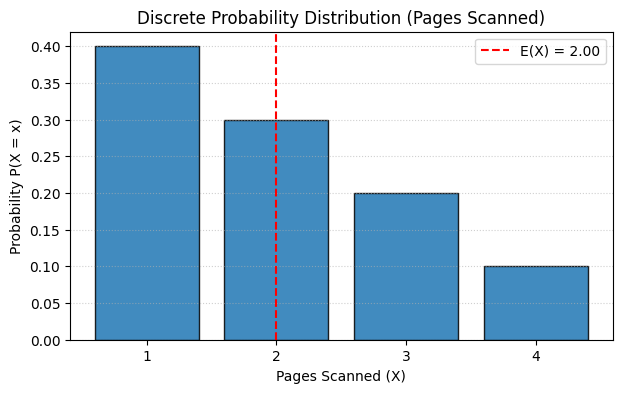

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define Outcomes (x) and Probabilities P(X=x)
x_vals = np.array([1, 2, 3, 4])
probs = np.array([0.40, 0.30, 0.20, 0.10])

# 2. Validate Sum Rule
assert np.isclose(np.sum(probs), 1.0), "Probabilities must sum to 1!"

# 3. Expected Value E(X)
expected_value = np.sum(x_vals * probs)

# 4. Variance and Standard Deviation
variance = np.sum(((x_vals - expected_value) ** 2) * probs)
std_dev = np.sqrt(variance)

# Print Summary Results
print(f"Expected Value E(X) : {expected_value:.2f}")
print(f"Variance Var(X)     : {variance:.2f}")
print(f"Standard Deviation  : {std_dev:.2f}")

# 5. Visualizing the PMF
plt.figure(figsize=(7, 4))
plt.bar(x_vals, probs, color='#1f77b4', edgecolor='black', alpha=0.85)
plt.axvline(expected_value, color='red', linestyle='--', label=f'E(X) = {expected_value:.2f}')
plt.title("Discrete Probability Distribution (Pages Scanned)", fontsize=12)
plt.xlabel("Pages Scanned (X)", fontsize=10)
plt.ylabel("Probability P(X = x)", fontsize=10)
plt.xticks(x_vals)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

In [ ]:

# Basic if_else check
test_score = 72
if test_score >= 50:
  print("Result:Pass")
else:
  print("Result:Fail")

Result:Pass


In [ ]:
import sys
# Multi-condition grading using if_elif_else
Marks = 84
if Marks >= 80:
   print("Grade:A")
elif Marks >= 65:
  print("Grade:B")
elif Marks >= 50:
  print("Grade:C")
else:
  print("Grade:Fail")

Grade:A


In [ ]:
#logical operators (AND)
age = 22
has_license = True
if age >= 18 and has_license:
  print("Eligible to drive")
else:
  print("Not eligible")

Eligible to drive


In [ ]:
#logical operators (OR)
day = "Saturday" # Assign a value to 'day'
if day == "Saturday" or day == "Sunday":
  print("it is weekend")
else:
  print("it is a weekday")

it is weekend


In [ ]:
#Checking if a list is empty
data_queue = []
if not data_queue:
  print("The queue is completely empty")
else:
  print("The queue contains data")

The queue is completely empty


In [ ]:
#loop through a list of items
Languages = ["Python","SQL","R","Julia"]
for Lang in Languages:
  print("programming language:", Lang)

programming language: Python
programming language: SQL
programming language: R
programming language: Julia


In [ ]:
#loop through range of numbers
for number in range (1,6):
  print("count:", number)

count: 1
count: 2
count: 3
count: 4
count: 5


In [ ]:
#calculating a running total using a for loop
monthly_expenses = [200,150,300,100]
total = 0
for expenses in monthly_expenses:
  total += expenses
print("Total expenses:",total)

Total expenses: 750


In [ ]:
#loop through dictionary keys and values
product_prices = {"keyboard":25,"mouse":15,"monitor":150}
for product,price in product_prices.items():
  print(product,"cost $",price)

keyboard cost $ 25
mouse cost $ 15
monitor cost $ 150


In [ ]:
import sys
#filtering data using a loop and an if statement
all_numbers = [12,45,8,23,60,3]
even_numbers = []
for num in all_numbers:
  if num % 2 == 0:
    even_numbers.append(num)
print("Even numbers only:",even_numbers)

Even numbers only: [12, 8, 60]


In [ ]:
#basic counter while loop
counter = 1
while counter <= 4:
  print ("iteration step:",counter)
  counter += 1

iteration step: 1
iteration step: 2
iteration step: 3
iteration step: 4


In [ ]:
#countdown loop
countdown = 5
while countdown > 0:
  print("launching in:", countdown)
  countdown -= 1
print("Blast off!")

launching in: 5
launching in: 4
launching in: 3
launching in: 2
launching in: 1
Blast off!


In [ ]:
i = 0
while i < 5:
  i += 1
  if i == 3:
    continue #skips printing 3
  print("value:",i)

value: 1
value: 2
value: 4
value: 5


In [ ]:
#processing elements until a list is empty
task_queue = ["clean data","analyze","export report"]
while task_queue :
  current_task = task_queue.pop(0)
  print("processing task:", current_task)
print("all tasks completed")

processing task: clean data
processing task: analyze
processing task: export report
all tasks completed


In [ ]:
#create a dictionary representing a student record
student_data = {"name":"Marizon",
                "course":"data analytics",
                "completed_lessons": 3 }

#access and print dictionary values
print("student:", student_data["name"])
print("course:", student_data["course"])

student: Marizon
course: data analytics


In [ ]:
#use for loop to iterate over a list of scores
scores = [63,75,82,90]
print("updated scores with 5_point boost:")
for original_scores in scores:
  boosted_score = original_scores + 5
  print(boosted_score)

updated scores with 5_point boost:
68
80
87
95


In [ ]:
import statistics
#dataset : daily number of users
user_counts = [12,18,15,12,23,100] #Note: 100 is an extreme outlier
#calculate mean and median to compare outlier impact
mean_val = statistics.mean(user_counts)
median_val = statistics.median(user_counts)
print("raw data:", user_counts)
print("mean(pulled by outlier):",mean_val)
print("median(resistant to outlier):", median_val)

raw data: [12, 18, 15, 12, 23, 100]
mean(pulled by outlier): 30
median(resistant to outlier): 16.5


In [ ]:
import numpy as np
import pandas as ps
import scipy.stats as stats
import matplotlib.pyplot as plt
#Daily transaction amount in KES (includes high outlier)
transactions = [100,120,130,150,160,180,200,210,250,5000]
#1. CENTRAL TENDENCY: SPECIALIZED MEAN
#Arithmetic mean
arithmetic_mean = np.mean(transactions)
#Geometric mean (used for growth and rates)
geom_mean = stats.gmean(transactions)
#Harmonic mean (used in average speeds or unit rates)
harm_mean = stats.hmean(transactions)
print("...1.SPECIALIZED MEAN...")
print("Arithmetic mean:", round(arithmetic_mean,2))
print("Geometric mean:", round(geom_mean,2))
print("Harmonic mean:", round(harm_mean,2))
print ("Relationship check (HM < GM < AM):", harm_mean < geom_mean < arithmetic_mean)
#2. DISPERSION AND RELATIVE VARIABILITY
#Standard deviation (sample SD using ddof = 1)
Stdev_val = np.std(transactions, ddof = 1)
#Interquartile Range (IQR)- Robust against outliers
iqr_val = stats.iqr(transactions)
#Coefficient of variation (c.v%)- valid for ratio scales
cv_val = (Stdev_val/arithmetic_mean)*100
print("\n...2.DISPERSION METRICS...")
print("Standard deviation:", round(Stdev_val,2))
print ("IQR(Q3-Q1):", round(iqr_val,2))
print("coefficient of variation (%):", round(cv_val,2))
#3.DISTRIBUTION SHAPE: SKEWNESS AND KURTOSIS
skew_val = stats.skew(transactions)
kurt_val = stats.kurtosis(transactions) #Returns excess kurtosis (normal = 0)
print("\n...3.SHAPE METRICS...")
print("skewness value:", round(skew_val,2))
if skew_val > 0:
   print("interpretation: positively skewed(Right tailed)")
elif skew_val < 0:
   print("interpretation: negatively skewed(Left tailed)")
else:
   print("interpretation: symmetrical")
print("excess kurtosis:", round(kurt_val,2))
if kurt_val > 0:
   print("Peak Type:Leptokurtic")
elif kurt_val < 0:
   print("Peak Type:Platykurtic")
else:
   print("Peak Type:Mesokurtic")
#4.CHEBYSHEV THEOREM ( for k = 2 S.D)
k = 2
chebyshev_min_pct = ( 1 - (1/(k**2)))*100
#calculate lower and upper boundaries for mean \u00b1 2 * S.D
lower_limit = arithmetic_mean - (k*Stdev_val)
upper_limit = arithmetic_mean + (k*Stdev_val)
#count observations within boundaries
count_within = sum(1 for x in transactions if lower_limit <= x <= upper_limit)
actual_pct = ( count_within/len(transactions))*100
print(f"\n...4.CHEBYSHEV THEOREM (k = {k})...")
print (f"Boundaries(mean \u00b1 2 S.D):[{round (lower_limit,2)},{round(upper_limit,2)}]")
print(f"Theoretical guaranteed minimum: {chebyshev_min_pct}%")
print(f"Actual percentage in data: {actual_pct}%")

...1.SPECIALIZED MEAN...
Arithmetic mean: 650.0
Geometric mean: 226.4
Harmonic mean: 171.06
Relationship check (HM < GM < AM): True

...2.DISPERSION METRICS...
Standard deviation: 1529.1
IQR(Q3-Q1): 72.5
coefficient of variation (%): 235.25

...3.SHAPE METRICS...
skewness value: 2.66
interpretation: positively skewed(Right tailed)
excess kurtosis: 5.1
Peak Type:Leptokurtic

...4.CHEBYSHEV THEOREM (k = 2)...
Boundaries(mean ± 2 S.D):[-2408.21,3708.21]
Theoretical guaranteed minimum: 75.0%
Actual percentage in data: 90.0%


In [ ]:
import numpy as np
import scipy.stats as stats

# Sample Dataset: Daily spending in KES with an outlier
spending = [100, 150, 200, 250, 5000]

# 1. Central Tendency
mean_val = np.mean(spending)
median_val = np.median(spending)

# 2. Dispersion Metrics
range_val = np.max(spending) - np.min(spending)
iqr_val = stats.iqr(spending)
sd_val = np.std(spending, ddof=1)

# 3. Shape Metric
skew_val = stats.skew(spending)

print("--- DESCRIPTIVE SUMMARY ---")
print("Mean:", mean_val)
print("Median:", median_val)
print("Range (Sensitive):", range_val)
print("IQR (Robust):", iqr_val)
print("Standard Deviation:", round(sd_val, 2))
print("Skewness Value:", round(skew_val, 2))

--- DESCRIPTIVE SUMMARY ---
Mean: 1140.0
Median: 200.0
Range (Sensitive): 4900
IQR (Robust): 100.0
Standard Deviation: 2158.53
Skewness Value: 1.5


In [ ]:
import numpy as np
import scipy.stats as stats

data = [10, 20, 30, 40, 1000]  # A dataset with an outlier

# 1. Use NumPy for basic summary metrics (Fast & Simple)
mean_value = np.mean(data)
median_value = np.median(data)
std_dev = np.std(data)

print("NumPy Mean:", mean_value)
print("NumPy Standard Deviation:", std_dev)

# 2. Use SciPy for advanced shape metrics (Complex & Scientific)
data_skewness = stats.skew(data)
data_kurtosis = stats.kurtosis(data)

print("SciPy Skewness (Asymmetry):", data_skewness)
print("SciPy Kurtosis (Tail Weight):", data_kurtosis)

NumPy Mean: 220.0
NumPy Standard Deviation: 390.1281840626232
SciPy Skewness (Asymmetry): 1.4975367033335198
SciPy Kurtosis (Tail Weight): 0.24671648930016365


Data Skewness: 1.4896509056341305


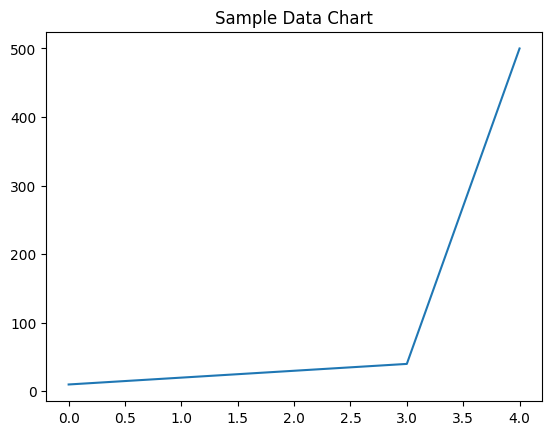

In [ ]:
# Step 1: Open our toolboxes (Libraries)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Step 2: Use NumPy to generate numbers
data = [10, 20, 30, 40, 500]

# Step 3: Use SciPy to check skewness
skew_val = stats.skew(data)
print("Data Skewness:", skew_val)

# Step 4: Use Matplotlib to plot the numbers
plt.plot(data)
plt.title("Sample Data Chart")
plt.show()

In [ ]:
# 1. Create a dictionary representing a student record
student_data = {
"name": " Marizon",
"course":"Data Analytics",
"completed_lessons":3
}

# 2. Access and print dictionary values
print("student:", student_data["name"])
print("course:", student_data["course"])

# 3. Use a for loop to iterate over a list of scores
scores = [ 63, 75, 82, 90]
print("updated scores with 5 points boost:")

for original_score in scores:
    boosted_score = original_score + 5
    print(boosted_score)

student:  Marizon
course: Data Analytics
updated scores with 5 points boost:
68
80
87
95


In [ ]:
import statistics
# Dataset: Daily number of users
user_counts = [ 12, 18, 15, 12, 23, 100]
# Note:100 is an extreme outlier

# Calculate mean and median to compare outlier impact
mean_val = statistics.mean(user_counts)
median_val = statistics.median(user_counts)

print("Raw Data:", user_counts)
print("mean(pulled by outlier):", mean_val)
print("median(Resistance to outlier):", median_val)

Raw Data: [12, 18, 15, 12, 23, 100]
mean(pulled by outlier): 30
median(Resistance to outlier): 16.5


In [ ]:
# Import Python's built-in statistics library
import statistics

# A new dataset (e.g., daily sales count)
daily_sales = [10, 14, 12, 10, 20, 18, 14]

# Calculate Median and Mode using the statistics library
median_val = statistics.median(daily_sales)
mode_val = statistics.multimode(daily_sales)  # Handles multiple modes if present

# Print the results
print("Sales Data:", daily_sales)
print("Sorted Data:", sorted(daily_sales))
print("Median:", median_val)
print("Mode(s):", mode_val)

Sales Data: [10, 14, 12, 10, 20, 18, 14]
Sorted Data: [10, 10, 12, 14, 14, 18, 20]
Median: 14
Mode(s): [10, 14]


In [ ]:
import pandas as pd

# Create a mini table (DataFrame) of store items
data = {
    'Item': ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Headphones'],
    'Price_USD': [800, 25, 45, 150, 60],
    'Units_Sold': [10, 50, 35, 20, 40]
}

# Convert dictionary into a Pandas DataFrame
df = pd.DataFrame(data)

# Calculate total revenue for each item
df['Total_Revenue'] = df['Price_USD'] * df['Units_Sold']

# Display the table and summary statistics
print("--- STORE DATA TABLE ---")
print(df)
print("\n--- SUMMARY STATISTICS ---")
print(df.describe())

--- STORE DATA TABLE ---
         Item  Price_USD  Units_Sold  Total_Revenue
0      Laptop        800          10           8000
1       Mouse         25          50           1250
2    Keyboard         45          35           1575
3     Monitor        150          20           3000
4  Headphones         60          40           2400

--- SUMMARY STATISTICS ---
        Price_USD  Units_Sold  Total_Revenue
count    5.000000    5.000000       5.000000
mean   216.000000   31.000000    3245.000000
std    329.950754   15.968719    2745.587369
min     25.000000   10.000000    1250.000000
25%     45.000000   20.000000    1575.000000
50%     60.000000   35.000000    2400.000000
75%    150.000000   40.000000    3000.000000
max    800.000000   50.000000    8000.000000


In [ ]:
student_name = "Marizon"

My_grades = [80, 85, 90]

Final_average = sum(My_grades)/ len(My_grades)

print(student_name)
print(Final_average)

Marizon
85.0


In [ ]:
# 1. Create a list of daily expenses in Kenyan shillings
Daily_expenses = [150 ,200 ,120 ,300 ,180]

# 2. Calculate total expenses and count number of days
Total_spent = sum(Daily_expenses)
Number_of_days = len(Daily_expenses)

# 3. Calculate average daily expenses (mean)
Average_expenses = Total_spent/ Number_of_days

# 4. Calculate the range (highest expenses minus lowest expenses)
Expenses_range = max(Daily_expenses) - min(Daily_expenses)

# 5. Print out the results
print("Total spent:", Total_spent )
print("Average daily expenses:", Average_expenses )
print("Expenses range:", Expenses_range )

Total spent: 950
Average daily expenses: 190.0
Expenses range: 180


In [ ]:
# Calculate Standard Deviation for My_grades
import statistics

std_dev_grades = statistics.stdev(My_grades)

print(f"Standard Deviation of My_grades: {std_dev_grades:.2f}")

Standard Deviation of My_grades: 5.00
